# EDA — Monitoreo AgroVoltaic (datos estandarizados)

Análisis exploratorio sobre la salida del pipeline (`src/agrovoltaic`), no sobre los CSV crudos.
Objetivo doble: **validar la limpieza** (¿desaparecieron temp 85, offset, negativos?) y
**explorar patrones** (cobertura temporal, faltantes, distribuciones, estacionalidad).

Cada sección termina con una **Interpretación** que dice qué esperar y cómo saber si está bien o mal.

> Calibración de irradiancia a W/m², Performance Ratio y features están **bloqueados**
> (lat/lon, kWp, timezone, modelo de piranómetro) — ver `docs/DUDAS-Pendientes.md`.

In [15]:
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.max_columns', 100)
print('OK')

OK


## Cargar datos estandarizados

Prioridad: Supabase (si hay `DATABASE_URL`) → `output/dry_run.csv` → reprocesar en vivo.

In [16]:
from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

from agrovoltaic import config

df = None
if os.getenv('DATABASE_URL'):
    try:
        import psycopg
        with psycopg.connect(os.environ['DATABASE_URL']) as conn:
            df = pd.read_sql(f'SELECT * FROM {config.TABLE_MAIN}', conn)
        print('Cargado desde Supabase:', len(df), 'filas')
    except Exception as e:
        print('Supabase falló:', e)

if df is None and config.DRY_RUN_CSV.exists():
    df = pd.read_csv(config.DRY_RUN_CSV)
    print('Cargado desde', config.DRY_RUN_CSV.name, ':', len(df), 'filas')

if df is None:
    from agrovoltaic import pipeline
    df = pipeline.dry_run()
    print('Reprocesado en vivo:', len(df), 'filas')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

rango_ok = (df['timestamp'].min().year == 2024) and (df['timestamp'].max().year == 2026)
n_ok = 25_000 <= len(df) <= 60_000
print('Rango:', df['timestamp'].min(), '->', df['timestamp'].max())
print('Veredicto:', 'OK' if (rango_ok and n_ok) else 'REVISAR (filas o rango fuera de lo esperado)')
df.shape

/tmp/ipykernel_45447/683673509.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f'SELECT * FROM {config.TABLE_MAIN}', conn)


Cargado desde Supabase: 36485 filas
Rango: 2024-11-10 13:10:00+00:00 -> 2026-06-01 17:55:00+00:00
Veredicto: OK


(36485, 31)

**Interpretación.** Esperado: ~36 k filas (285 CSV resampleados a 5 min) y rango Nov-2024 → Jun-2026.
- **Bien** si el veredicto es OK.
- **Mal** si hay muchas menos filas (CSV no cargados o `_ingest_log` saltando archivos) o el rango
  arranca/termina raro (timestamps mal parseados → revisar `extract.parse_timestamp`).

## Vista general

In [17]:
print('Días con datos:', df['timestamp'].dt.normalize().nunique())
df.describe().T[['min', 'max', 'mean', 'count']]

Días con datos: 274


,min,max,mean,count
voltaje_pv1_v,-38.845008,1.002571e+03,163.891787,35896.0
corriente_pv1_a,-0.310463,1.202681e+03,2.465570,35902.0
potencia_pv1_w,0.000000,2.650316e+07,1093.123787,34365.0
voltaje_pv2_v,-37.902716,1.967331e+02,147.822740,34029.0
corriente_pv2_a,0.000000,8.404647e+02,1.627670,32489.0
potencia_pv2_w,0.000000,1.379460e+03,222.250190,32489.0
potencia_total_wac,0.000000,1.186339e+05,546.500941,19890.0
frecuencia_hz,59.776000,6.006000e+01,60.004475,16043.0
voltaje_vac,100.209524,2.188400e+02,212.805181,26400.0
corriente_aac,0.000000,1.114500e+01,2.439652,34335.0


**Interpretación.** Mirá `min`/`max` por columna y comparalos con la física esperada:
- Voltajes PV 0–~600 V, potencias **≥ 0**, `frecuencia_hz` ~60, `voltaje_vac` 100–280.
- Temperaturas dentro de −10…70 (NUNCA 85.0).
- **Bien** si todo cae en esos rangos. **Mal** si hay potencias negativas, temp = 85, o una
  columna con escala absurda. Nota: algunas columnas tienen outliers crudos enormes (p.ej.
  `potencia_pv1_w` max de millones) que se recortan más abajo para los gráficos.

## Cobertura temporal

Muestras por mes y detección de gaps (brechas largas conocidas: 126 y 71 días).

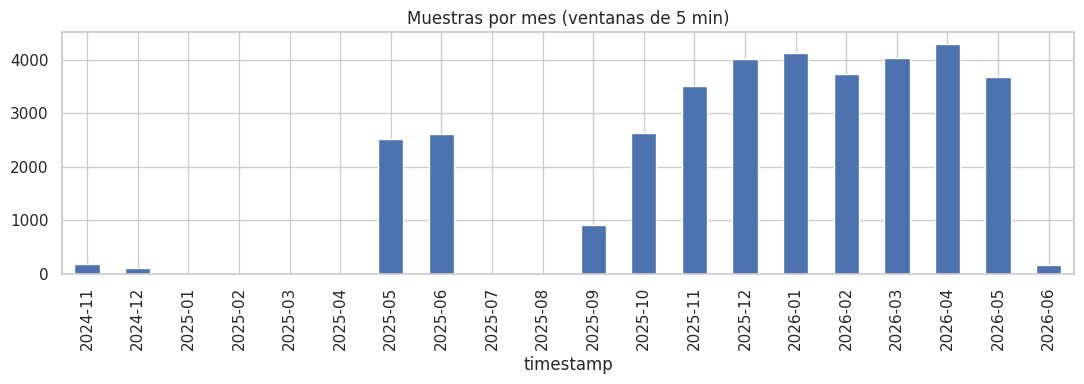

In [18]:
por_mes = df.set_index('timestamp').resample('MS').size()
por_mes.index = por_mes.index.strftime('%Y-%m')  # string: evita el conversor de Period (pandas 3.0)
ax = por_mes.plot(kind='bar')
ax.set_title('Muestras por mes (ventanas de 5 min)')
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

**Interpretación.** Las barras muestran cuánto dato hay por mes. Los meses llenos rondan ~4.000-4.300
ventanas (el datalogger registra sobre todo de día, no 24 h); lo importante es la FORMA.
- **Bien** si la mayoría de los meses tienen datos y se ven los huecos conocidos de 2025.
- **Mal** si TODOS los meses están bajos (problema de resampleo) o falta un mes que sí debería estar.

In [19]:
# Gaps: días consecutivos sin ningún dato
dias = pd.Series(df['timestamp'].dt.normalize().unique()).sort_values()
saltos = dias.diff().dt.days
gaps = [(dias.iloc[i-1], dias.iloc[i], int(saltos.iloc[i]))
        for i in range(1, len(dias)) if saltos.iloc[i] and saltos.iloc[i] > 2]
for ini, fin, n in sorted(gaps, key=lambda x: -x[2])[:15]:
    print(f'  {ini.date()} -> {fin.date()} : {n} días sin datos')

maxg = max((n for *_, n in gaps), default=0)
print('\nVeredicto:', 'OK (aparecen los gaps conocidos ~126 y ~71 días)'
      if maxg >= 100 else 'REVISAR (no aparece el gap largo esperado)')

  2024-12-29 -> 2025-05-04 : 126 días sin datos
  2025-06-26 -> 2025-09-05 : 71 días sin datos
  2024-11-21 -> 2024-12-23 : 32 días sin datos
  2025-09-05 -> 2025-09-22 : 17 días sin datos
  2024-11-11 -> 2024-11-21 : 10 días sin datos
  2025-05-26 -> 2025-06-03 : 8 días sin datos
  2025-10-07 -> 2025-10-14 : 7 días sin datos
  2026-03-04 -> 2026-03-09 : 5 días sin datos
  2025-05-10 -> 2025-05-14 : 4 días sin datos
  2025-10-21 -> 2025-10-25 : 4 días sin datos
  2025-10-30 -> 2025-11-03 : 4 días sin datos
  2026-05-21 -> 2026-05-25 : 4 días sin datos
  2025-06-09 -> 2025-06-12 : 3 días sin datos

Veredicto: OK (aparecen los gaps conocidos ~126 y ~71 días)


**Interpretación.** Los dos gaps grandes (126 días Dic-2024→May-2025 y 71 días Jun→Sep-2025) están
documentados en el EDA del crudo.
- **Bien** si aparecen acá: confirma que NO se inventaron datos para tapar los huecos (decisión tomada).
- **Mal** si NO aparecen (alguien rellenó los gaps) o si hay gaps nuevos no esperados.

In [20]:
# Intervalo de muestreo original (2s, 1min, 5min según época)
if 'intervalo_original_seg' in df:
    print(df['intervalo_original_seg'].describe())
    print('\nMuestras por intervalo (agrupado):')
    print(pd.cut(df['intervalo_original_seg'], [0, 10, 90, 400]).value_counts())

count    36483.000000
mean       243.831894
std        112.750211
min          2.000000
25%        165.000000
50%        300.000000
75%        315.000000
max        330.000000
Name: intervalo_original_seg, dtype: float64

Muestras por intervalo (agrupado):
intervalo_original_seg
(90, 400]    27718
(10, 90]      8215
(0, 10]        550
Name: count, dtype: int64


**Interpretación.** `intervalo_original_seg` es cada cuánto medía el datalogger ANTES de resamplear
(quedó como metadato). Esperado: 3 regímenes — ~2-8 s (Dic-2024), ~30-60 s (2025), ~300 s (2025-2026).
- **Bien** si se ven esos tres grupos: confirma el muestreo variable que motivó el resampleo a 5 min.
- **Mal** si todo cae en un solo valor (no se detectó la variación) o hay intervalos > 600 s raros.

## Datos faltantes

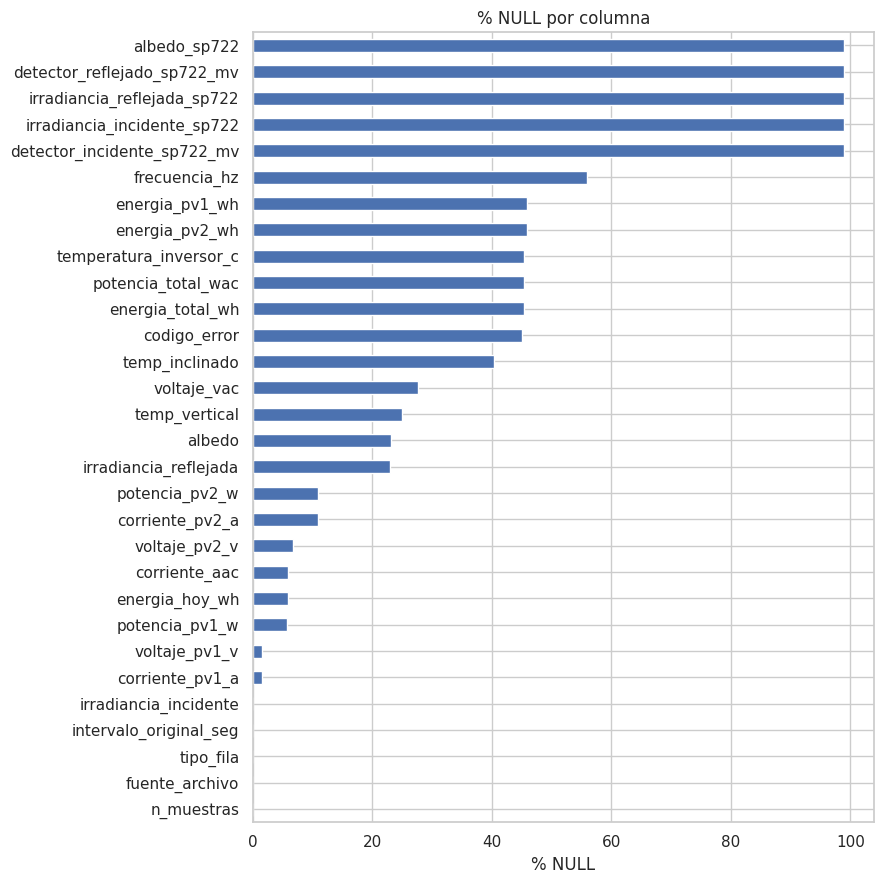

Columnas con >50% NULL NO esperadas: ninguna (OK)


In [21]:
nulls = df.drop(columns=['timestamp']).isna().mean().mul(100).sort_values()
ax = nulls.plot(kind='barh', figsize=(9, 9))
ax.set_title('% NULL por columna'); ax.set_xlabel('% NULL')
plt.tight_layout(); plt.show()

esperado_alto = {'irradiancia_incidente_sp722', 'irradiancia_reflejada_sp722',
                 'detector_incidente_sp722_mv', 'detector_reflejado_sp722_mv', 'albedo_sp722',
                 'energia_total_wh', 'energia_pv1_wh', 'energia_pv2_wh', 'frecuencia_hz',
                 'potencia_total_wac', 'temperatura_inversor_c', 'codigo_error', 'voltaje_vac'}
inesperado = [c for c in nulls.index if nulls[c] > 50 and c not in esperado_alto]
print('Columnas con >50% NULL NO esperadas:', inesperado or 'ninguna (OK)')

**Interpretación.** Hay NULLs estructurales legítimos:
- `*_sp722` ~99 % (sensor nuevo desde May-2026); AC/energía/inversor altas porque NO existen en todos
  los schemas históricos. `potencia_total_wac` ~45 % es **esperado**: en los ~123 archivos snake la
  columna `potencia_total_va` viene vacía en el origen.
- **Bien** si la línea de arriba dice *ninguna*: todo el NULL alto es explicable.
- **Mal** si aparece una columna núcleo (`irradiancia_incidente`, `potencia_pv1_w`, `temp_vertical`)
  con >50 % NULL → señal de mapeo roto.

## Distribuciones de variables clave

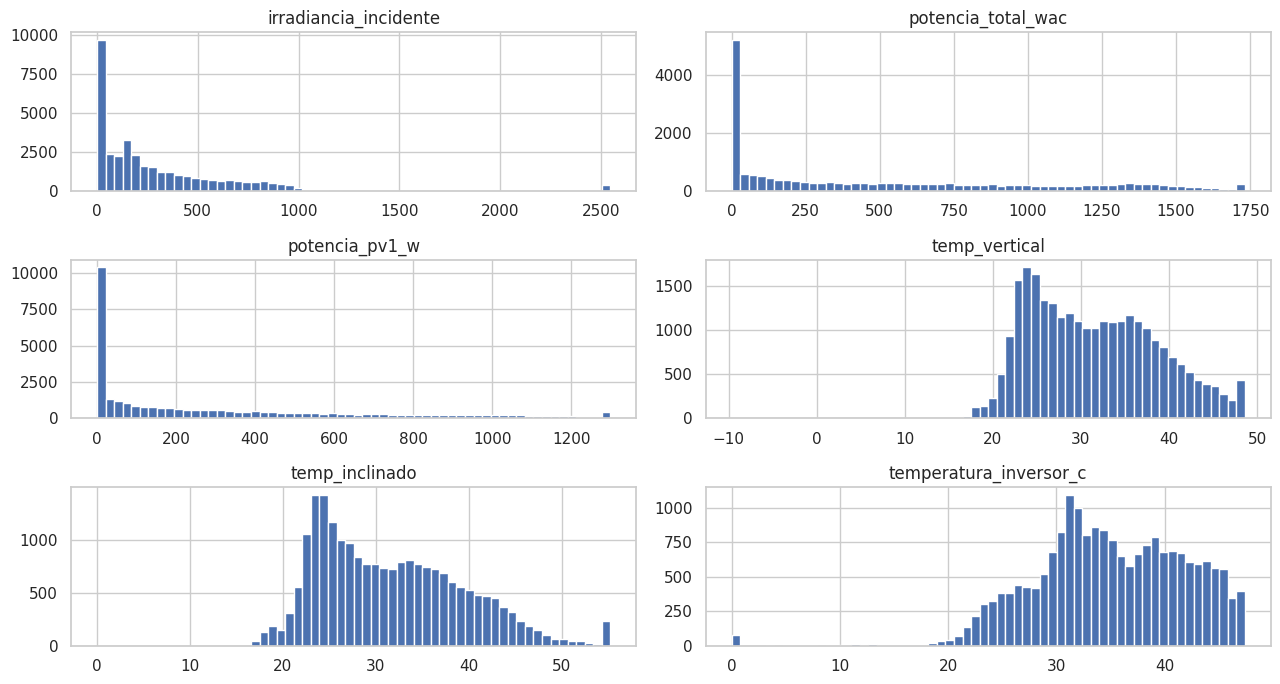

,min,max,mean
irradiancia_incidente,0.000000,1.064353e+04,330.473766
potencia_total_wac,0.000000,1.186339e+05,546.500941
potencia_pv1_w,0.000000,2.650316e+07,1093.123787
temp_vertical,-9.690429,6.980338e+01,31.502402
temp_inclinado,0.000000,6.997905e+01,31.710063
temperatura_inversor_c,0.000000,5.090000e+01,34.894717


In [22]:
cols = [c for c in ['irradiancia_incidente', 'potencia_total_wac', 'potencia_pv1_w',
                    'temp_vertical', 'temp_inclinado', 'temperatura_inversor_c']
        if c in df]
# Recortar a percentil 99 por columna solo para visualizar (no altera los datos)
vis = df[cols].clip(upper=df[cols].quantile(0.99), axis=1)
vis.hist(bins=60, figsize=(13, 7)); plt.tight_layout(); plt.show()
df[cols].describe().T[['min', 'max', 'mean']]

**Interpretación.** Forma esperada (histogramas recortados a p99 para que se vean):
- `irradiancia_incidente`: pico grande en 0 (noche) y una cola hacia valores altos (día). Sin negativos.
- Potencias: pico en 0 (noche/inversor apagado), cola positiva de día. Nunca negativas.
- Temperaturas: campana entre ~10 y ~50 °C, **sin** barra en 85.
- **Bien** si se ven así. **Mal** si hay masa en negativos o una barra aislada en 85 (mirá la tabla
  `min`/`max` sin recortar para confirmar).

## Relaciones físicas

Irradiancia vs potencia (deberían correlacionar) y perfil diario promedio.

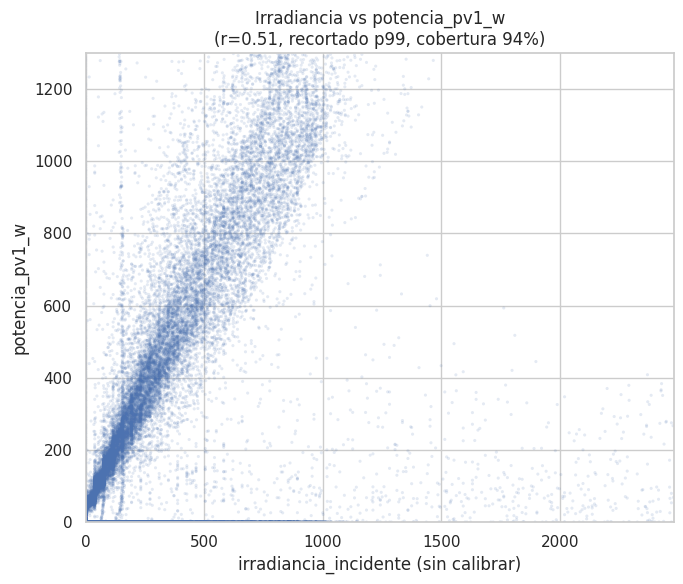

Columna usada: potencia_pv1_w (94% no-null)
Veredicto: OK aceptable (correlación moderada; sube al calibrar la irradiancia)


In [23]:
# Columna de potencia mas completa (densa en todo el rango)
cobertura = {c: df[c].notna().mean() for c in ['potencia_pv1_w', 'potencia_total_wac'] if c in df}
pot = max(cobertura, key=cobertura.get)
sub = df[['irradiancia_incidente', pot]].dropna()

# Recortar outliers (percentil 99 en ambos ejes) para que el grafico no se aplaste
qx = sub['irradiancia_incidente'].quantile(0.99)
qy = sub[pot].quantile(0.99)
sub = sub[(sub['irradiancia_incidente'] <= qx) & (sub[pot] <= qy)]

r = sub.corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sub['irradiancia_incidente'], sub[pot], s=5, alpha=0.15, edgecolors='none')
ax.set_xlim(0, qx); ax.set_ylim(0, qy)
ax.set_xlabel('irradiancia_incidente (sin calibrar)'); ax.set_ylabel(pot)
ax.set_title(f'Irradiancia vs {pot}\n(r={r:.2f}, recortado p99, cobertura {cobertura[pot]*100:.0f}%)')
plt.tight_layout(); plt.show()

if r > 0.6:
    veredicto = 'OK (correlación fuerte)'
elif r > 0.35:
    veredicto = 'OK aceptable (correlación moderada; sube al calibrar la irradiancia)'
else:
    veredicto = 'REVISAR (correlación débil: filas mezcladas o columna mal mapeada)'
print('Columna usada:', pot, f'({cobertura[pot]*100:.0f}% no-null)')
print('Veredicto:', veredicto)

**Interpretación.** Más sol → más potencia, así que la nube debe subir de izquierda a derecha.
Se usa la columna de potencia más completa y se recortan outliers (p99) para que el gráfico sea legible.
- **Bien** con `r` moderado/alto (> 0.35) y nube creciente: irradiancia y potencia son coherentes
  entre sí (aunque la irradiancia siga sin calibrar; eso baja `r` un poco).
- **Mal** si `r` ~0 o la nube no tiene forma → posible mezcla de filas (Paso 2) o columna mal mapeada.

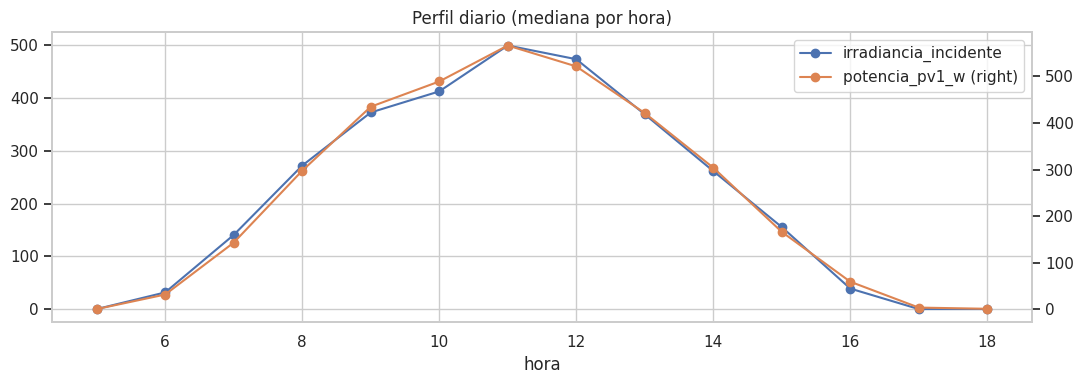

Pico de irradiancia a las 11:00 en los timestamps guardados.
Sol ~5-18h y pico ~11-12h sugieren que los timestamps son HORA LOCAL, no UTC (dato para el bloqueante de timezone).


In [24]:
# Perfil diario por hora — MEDIANA sobre filas del inversor (potencia no nula).
# Robusta a outliers; excluye las filas 'sensor' con irradiancia cruda anomala.
base = df.dropna(subset=[pot]).assign(hora=lambda d: d['timestamp'].dt.hour)
perfil = base.groupby('hora')[['irradiancia_incidente', pot]].median()
perfil.plot(secondary_y=[pot], marker='o', title='Perfil diario (mediana por hora)')
plt.tight_layout(); plt.show()

hora_pico = int(perfil['irradiancia_incidente'].idxmax())
print(f'Pico de irradiancia a las {hora_pico}:00 en los timestamps guardados.')
print('Sol ~5-18h y pico ~11-12h sugieren que los timestamps son HORA LOCAL, no UTC '
      '(dato para el bloqueante de timezone).')

**Interpretación.** Esperado: campana diurna — casi 0 de madrugada, sube, pico cerca del mediodía,
baja al atardecer. Las dos curvas (irradiancia y potencia) deben coincidir en horario.
- **Bien** con esa campana centrada al mediodía.
- **Mal** si el pico está corrido a horas raras → posible problema de **timezone** (bloqueante abierto:
  UTC-4 vs UTC-6) o de timestamps.

## Estacionalidad

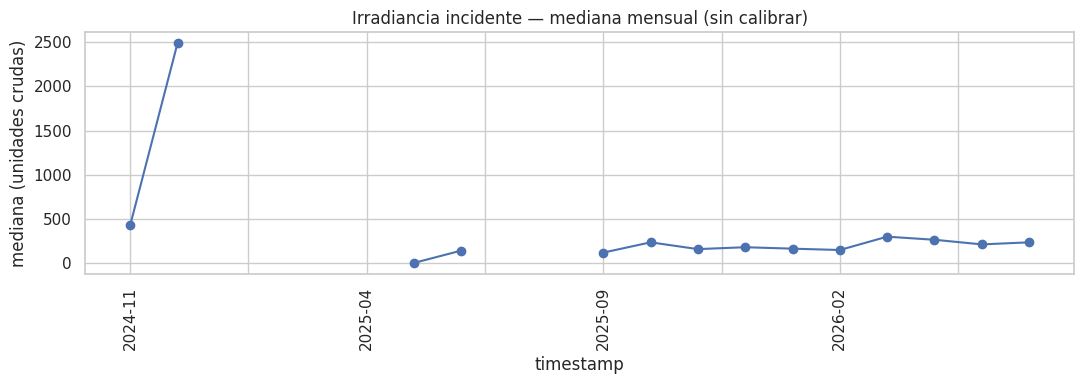

OJO: Dic-2024 queda en otra escala (~10x): es la época de muestreo a 2 s, sin calibrar.
La escala de irradiancia cambia entre épocas -> meses NO comparables hasta calibrar.


In [25]:
# Estacionalidad — MEDIANA mensual (robusta; la media la inflan los outliers crudos)
mensual = df.set_index('timestamp')['irradiancia_incidente'].resample('MS').median()
mensual.index = mensual.index.strftime('%Y-%m')  # string: evita el conversor de Period (pandas 3.0)
ax = mensual.plot(marker='o', title='Irradiancia incidente — mediana mensual (sin calibrar)')
ax.set_ylabel('mediana (unidades crudas)')
plt.xticks(rotation=90); plt.tight_layout(); plt.show()
print('OJO: Dic-2024 queda en otra escala (~10x): es la época de muestreo a 2 s, sin calibrar.')
print('La escala de irradiancia cambia entre épocas -> meses NO comparables hasta calibrar.')

**Interpretación.** Debería verse un patrón estacional suave (más irradiancia en meses de verano del
hemisferio sur, menos en invierno), sin saltos imposibles entre meses contiguos.
- **Bien** si la curva es continua y con tendencia estacional.
- **Mal** si un mes se dispara/cae a un valor absurdo (outliers no filtrados) — recordar que la
  escala es cruda, así que importa la FORMA, no el valor absoluto (la calibración está pendiente).

## Validación de la limpieza (crudo vs limpio)

Lo más importante: confirmar que en los datos limpios YA no quedan los errores conocidos.

In [26]:
temp_cols = [c for c in ['temp_vertical', 'temp_inclinado', 'temperatura_inversor_c'] if c in df]
n85 = int((df[temp_cols] == 85.0).sum().sum())
n_neg_irr = int((df[['irradiancia_incidente', 'irradiancia_reflejada']] < 0).sum().sum())
print('LIMPIO -> temp==85.0:', n85, '| irradiancia<0:', n_neg_irr)
print('Veredicto:', 'OK (limpieza aplicada)' if (n85 == 0 and n_neg_irr == 0)
      else 'MAL (la limpieza no se aplicó a todo)')

LIMPIO -> temp==85.0: 0 | irradiancia<0: 0
Veredicto: OK (limpieza aplicada)


**Interpretación.** Esto es un test pasa/falla del pipeline.
- **Bien** si ambos son 0: la regla temp 85 → NULL y la de negativos → 0 funcionaron en TODO el dataset.
- **Mal** si alguno es > 0: quedó data sucia → revisar `transform.clean_temperatures` /
  `clean_irradiance`. La siguiente celda cuantifica cuánto había en el crudo (debe ser >> 0).

In [27]:
# Conteos en CRUDO (antes de limpiar): escanear todos los CSV con extract (sin transform)
import importlib
from agrovoltaic import extract
importlib.reload(extract)  # evita módulo cacheado si se editó normalize/extract
raw85 = raw_off = raw_neg = filas = 0
for p in sorted(config.DATASET_DIR.glob('*.csv')):
    try:
        r = extract.to_numeric(extract.normalize_columns(extract.read_raw_csv(p)))
    except Exception:
        continue
    filas += len(r)
    tc = [c for c in ['temp_vertical', 'temp_inclinado', 'temperatura_inversor_c'] if c in r]
    raw85 += int((r[tc] == 85.0).sum().sum())
    irr = r[['irradiancia_incidente', 'irradiancia_reflejada']]
    raw_off += int(np.isclose(irr, config.OFFSET_NOCTURNO, atol=1e-3).sum())
    raw_neg += int((irr < 0).sum().sum())
print(f'CRUDO ({filas} filas) -> temp==85: {raw85} | offset -38.845: {raw_off} | irradiancia<0: {raw_neg}')

Monitoreo_2024-12-27.csv: 18513 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)
Monitoreo_2024-12-28.csv: 18467 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)
Monitoreo_2024-12-29.csv: 18522 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)
Monitoreo_2025-05-20.csv: 137 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)
Monitoreo_2025-10-18.csv: 421 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)
Monitoreo_2025-10-20.csv: 3 filas con nº de columnas distinto al header, saltadas (filas mezcladas — pendiente Paso 2)


CRUDO (115012 filas) -> temp==85: 24585 | offset -38.845: 3731 | irradiancia<0: 25388


**Interpretación.** Estos conteos deben ser **grandes** (miles): demuestran que el crudo SÍ tenía esos
errores y que la sección anterior (limpio = 0) no es trivial.
- **Bien** si crudo ≫ 0 y limpio = 0 → la limpieza realmente corrigió algo medible.
- Nota: si aparecen warnings `Columna desconocida ignorada` en rojo, reiniciá el kernel (módulo
  `normalize` viejo en caché); no afecta los conteos de temp/irradiancia.

## Procedencia y sensor SP722

In [28]:
if 'tipo_fila' in df:
    print('tipo_fila:'); print(df['tipo_fila'].value_counts())
sp = [c for c in df.columns if 'sp722' in c]
if sp:
    nn = df.loc[df[sp].notna().any(axis=1), 'timestamp']
    print('\nSP722 — desde:', nn.min() if len(nn) else 'sin datos', '| filas con SP722:', len(nn))

tipo_fila:
tipo_fila
inversor    36060
sensor        425
Name: count, dtype: int64

SP722 — desde: 2026-05-11 09:20:00+00:00 | filas con SP722: 360


**Interpretación.**
- `tipo_fila`: la mayoría debe ser `inversor` y una minoría `sensor` (lecturas de solo-piranómetro).
  **Bien** si domina `inversor`. **Mal** si casi todo es `sensor` → la clasificación de filas falló.
- SP722 debe arrancar a mediados de **May-2026** (sensor recién instalado). **Bien** si la fecha 'desde'
  cae ahí. **Mal** si aparece SP722 en 2024/2025 → columna mal asignada.

## Conclusiones

Si **Cargar datos**, **Datos faltantes**, **Relaciones físicas** y **Validación de la limpieza**
dieron OK, los datos estandarizados están sanos y listos para Supabase / dashboard.

- La limpieza eliminó temp=85, offset −38.845 y negativos (la validación lo cuantifica crudo vs limpio).
- Cobertura confirma los gaps largos conocidos y el intervalo variable.
- **Irradiancia sigue sin calibrar** (unidades crudas): la correlación con potencia sirve de
  sanity check, pero los valores absolutos NO son W/m² todavía.
- SP722 casi vacío salvo el tramo reciente.

